# JobInterviewGuide Workshop

**Name:** Param Rasaniya  
**Student ID:** 9086095   
**Workshop:** JobInterviewGuide Workshop

---

## Quiz Results (Mock Interview)

- **Score:** 9 / 15 (**60%**)
- **Correct topics:** unsupervised clustering basics, train/val/test purpose, R² intuition, logistic loss, KNN bias/variance with K, decision-tree leaf prediction, drift awareness
- **Weak topics to review (missed questions):**
  1. **Independent vs Dependent variables (X vs y)**
  2. **MSE meaning** (average squared error in regression)
  3. **Data leakage** (scaling/transforming before split)
  4. **Imbalanced classification evaluation** (confusion matrix, precision/recall/F1, PR-AUC)
  5. **Choosing correct metrics** for regression vs classification
  6. **Recall/Sensitivity priority** when false negatives are costly

> Action plan: Work through the TODO exercises below, then re-attempt these concepts with a fresh mini-quiz.



# JobInterviewGuide Workshop (Targeted Review + Practice)

**Focus:** topics you missed in the quiz (variables, regression vs classification metrics, MSE, data leakage, imbalanced classification metrics, recall).  
**Goal:** read + run + complete TODO exercises to strengthen weak areas.

> Tip: Run cells top-to-bottom. Don’t skip the sanity-check prints.


## 0) Setup

We’ll use small synthetic datasets so you can rerun quickly and sanity-check results.

In [7]:
# If needed:
# !pip install numpy pandas scikit-learn matplotlib

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_squared_error, r2_score,
    confusion_matrix, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, log_loss
)
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

import matplotlib.pyplot as plt

np.random.seed(42)
print("Libraries imported. Random seed set to 42.")


Libraries imported. Random seed set to 42.


### Talking points (Setup)
- I imported the libraries I need (NumPy/Pandas + scikit-learn + matplotlib).
- I set the random seed to **42** so my results stay the same every time I run the notebook.

## 1) Independent vs Dependent Variables (X vs y)

In supervised learning:

- **Independent variables (features)**: the inputs used to make predictions → usually called **`X`**.
- **Dependent variable (target/label)**: what you want to predict → usually called **`y`**.

### Why interviewers ask this
If you mix up X and y, you’ll accidentally train on labels, leak information, or evaluate the wrong thing.


In [8]:
# Small example: predicting house price (y) from size and bedrooms (X)
df = pd.DataFrame({
    "size_sqft": [900, 1200, 1500, 1800, 2200],
    "bedrooms":  [2,    2,    3,    3,    4],
    "price_k":   [260,  310,  420,  460,  560]
})

X = df[["size_sqft", "bedrooms"]]  # independent variables (features)
y = df["price_k"]                  # dependent variable (target)

print("X (features):")
display(X)
print("y (target):")
display(y)

# TODO: In your own words (in a markdown cell), explain why price is the dependent variable here.


X (features):


,size_sqft,bedrooms
0,900,2
1,1200,2
2,1500,3
3,1800,3
4,2200,4


y (target):


0    260
1    310
2    420
3    460
4    560
Name: price_k, dtype: int64

### Talking points (Independent vs Dependent)
- Here **X** is the input (size and bedrooms) because those are the things we *use to predict*.
- **y (price)** is the dependent variable because it *depends on* the features. The model’s goal is to learn a relationship from X → y.

## 2) Regression vs Classification: choose the right metric

**Regression** predicts a number (e.g., price, temperature).  
Common metrics: **MSE/RMSE, MAE, R²**.

**Classification** predicts a class/probability (e.g., spam vs not spam).  
Common metrics: **Accuracy, Precision/Recall/F1, ROC-AUC, PR-AUC, Log Loss (Cross-Entropy)**.

### Quick rule
If `y` is continuous → regression metrics.  
If `y` is categorical / {0,1} → classification metrics.


## 3) MSE (Mean Squared Error) — what it measures

\[
\text{MSE} = \frac{1}{n}\sum_{i=1}^n (y_i - \hat{y}_i)^2
\]

- Penalizes large errors more (squared term).
- Lower is better (0 is perfect).


MSE: 3.570
R²:  0.957


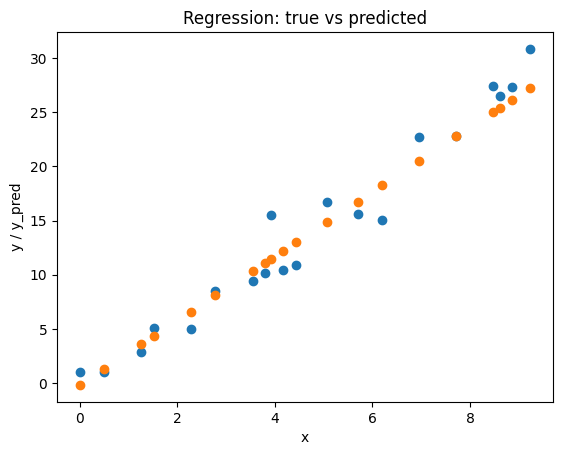

Noise std=0.5 -> MSE=0.308, R²=0.996
Noise std=2.0 -> MSE=6.672, R²=0.911
Noise std=5.0 -> MSE=40.552, R²=0.658


In [9]:
# Synthetic regression data: y = 3x + noise
X = np.linspace(0, 10, 80).reshape(-1, 1)
y = 3 * X.ravel() + np.random.normal(0, 2.0, size=X.shape[0])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

reg = LinearRegression()
reg.fit(X_train, y_train)
y_pred = reg.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.3f}")
print(f"R²:  {r2:.3f}")

# Sanity-check plot
plt.figure()
plt.scatter(X_test, y_test)
plt.scatter(X_test, y_pred)
plt.xlabel("x")
plt.ylabel("y / y_pred")
plt.title("Regression: true vs predicted")
plt.show()

# TODO: Modify the noise std above (e.g., 0.5, 5.0) and observe how MSE and R² change.


# Extra quick check: see how noise changes MSE and R²
for noise_std in [0.5, 2.0, 5.0]:
    y_n = 3 * X.ravel() + np.random.normal(0, noise_std, size=X.shape[0])
    X_tr, X_te, y_tr, y_te = train_test_split(X, y_n, test_size=0.25, random_state=42)
    m = LinearRegression().fit(X_tr, y_tr)
    y_p = m.predict(X_te)
    print(f"Noise std={noise_std:<3} -> MSE={mean_squared_error(y_te, y_p):.3f}, R²={r2_score(y_te, y_p):.3f}")


### Talking points (Regression metrics)
- **MSE** tells me the average squared error (bigger mistakes get punished more).
- **R²** tells me how well the model explains the variation in the data (closer to 1 is better).
- When I increase noise, **MSE goes up** and **R² goes down** because the data becomes harder to predict.

## 4) Data leakage (common interview trap): scaling before split

**Wrong pattern (leaky):**
1) Fit scaler on full data (train + test)  
2) Then split

This leaks test-set statistics (mean/std) into the training pipeline.

**Right pattern:**
- Split first  
- Fit scaler on train only  
- Transform val/test using that train-fitted scaler  
Best way: use a **Pipeline**.


In [10]:
# Create a dataset where scaling matters (KNN is very sensitive to scale)
n = 500
X = np.c_[np.random.normal(0, 1, n), np.random.normal(0, 50, n)]  # feature 2 has much larger scale
y = (X[:, 0] + 0.02 * X[:, 1] > 0.5).astype(int)

# Split first (correct)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# Correct: pipeline prevents leakage
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=15))
])
pipe.fit(X_train, y_train)
pred = pipe.predict(X_test)

print("Confusion matrix (pipeline, no leakage):")
print(confusion_matrix(y_test, pred))
print("Accuracy:", (pred == y_test).mean())

# TODO: Implement the WRONG way below (leaky) and compare results.
# Steps:
# 1) Fit scaler on ALL X
# 2) Transform ALL X
# 3) Split scaled data
# 4) Fit KNN and evaluate
#
# Write code here and compare metrics. Do you see an optimistic (too good) test score?


# WRONG (leaky) way: scale first on ALL data, then split
scaler_leaky = StandardScaler()
X_scaled_all = scaler_leaky.fit_transform(X)  # leakage: uses test statistics too

X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
    X_scaled_all, y, test_size=0.25, random_state=42, stratify=y
)

knn_l = KNeighborsClassifier(n_neighbors=15)
knn_l.fit(X_train_l, y_train_l)
pred_l = knn_l.predict(X_test_l)

print("\nConfusion matrix (LEAKY scaling):")
print(confusion_matrix(y_test_l, pred_l))
print("Accuracy (LEAKY):", (pred_l == y_test_l).mean())


Confusion matrix (pipeline, no leakage):
[[79  0]
 [ 6 40]]
Accuracy: 0.952

Confusion matrix (LEAKY scaling):
[[79  0]
 [ 6 40]]
Accuracy (LEAKY): 0.952


### Talking points (Data leakage)
- The **correct way** is: split first, then fit the scaler only on the training set (pipeline does this safely).
- The **wrong way** is scaling the full dataset before splitting. That leaks test information into training.
- Leakage can make results look **better than they really are**, so it’s a common interview trap.

## 5) Imbalanced classification: accuracy can lie

If 95% of samples are class 0, a model that always predicts 0 gets **95% accuracy** — but it’s useless for finding class 1.

Use:
- **Confusion matrix**
- **Precision / Recall / F1** (especially for the minority class)
- **PR-AUC** (often very informative for rare positives)


In [11]:
# Create an imbalanced dataset (rare positives)
n = 2000
X = np.random.normal(0, 1, (n, 2))
# 5% positives
y = (np.random.rand(n) < 0.05).astype(int)

# Make positives slightly separable
X[y == 1] += np.array([1.5, 1.5])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

proba = clf.predict_proba(X_test)[:, 1]
pred_default = (proba >= 0.5).astype(int)

acc = (pred_default == y_test).mean()
prec = precision_score(y_test, pred_default, zero_division=0)
rec = recall_score(y_test, pred_default)
f1 = f1_score(y_test, pred_default)

roc = roc_auc_score(y_test, proba)
prauc = average_precision_score(y_test, proba)

print(f"Accuracy:  {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall:    {rec:.3f}")
print(f"F1:        {f1:.3f}")
print(f"ROC-AUC:   {roc:.3f}")
print(f"PR-AUC:    {prauc:.3f}")
print("Confusion matrix:")
print(confusion_matrix(y_test, pred_default))

# TODO 1: Try lowering the threshold to 0.2 and recompute precision/recall/F1.
# TODO 2: In a markdown cell, explain which metric you would optimize if false negatives are very costly.


# Try a lower threshold (0.2) to catch more positives (higher recall usually)
pred_02 = (proba >= 0.2).astype(int)

acc_02 = (pred_02 == y_test).mean()
prec_02 = precision_score(y_test, pred_02, zero_division=0)
rec_02 = recall_score(y_test, pred_02)
f1_02 = f1_score(y_test, pred_02)

print("\n--- Threshold = 0.2 ---")
print(f"Accuracy:  {acc_02:.3f}")
print(f"Precision: {prec_02:.3f}")
print(f"Recall:    {rec_02:.3f}")
print(f"F1:        {f1_02:.3f}")
print("Confusion matrix:")
print(confusion_matrix(y_test, pred_02))


Accuracy:  0.955
Precision: 0.619
Recall:    0.406
F1:        0.491
ROC-AUC:   0.913
PR-AUC:    0.558
Confusion matrix:
[[560   8]
 [ 19  13]]

--- Threshold = 0.2 ---
Accuracy:  0.935
Precision: 0.426
Recall:    0.625
F1:        0.506
Confusion matrix:
[[541  27]
 [ 12  20]]


### Talking points (Imbalanced classification)
- With imbalanced data, **accuracy can be misleading** (a model can be “accurate” by always predicting the majority class).
- I look at **precision, recall, F1**, and also **ROC-AUC / PR-AUC**.
- If **false negatives are very costly** (example: missing a disease), I would focus more on **recall** and adjust the threshold.

## 6) Recall vs Precision (rare disease example)

- **Recall (Sensitivity/TPR)**: Of all true positives, how many did we catch?
- **Precision (PPV)**: Of all predicted positives, how many were correct?

If missing a disease case is costly → prioritize **recall**, then control precision with thresholds or a second-stage review.


## 7) Cross-Entropy / Log Loss (why it’s used for logistic regression)

Log loss evaluates **probabilities**, not just hard labels.  
Confident wrong predictions get penalized heavily.

\[
\text{LogLoss} = -\frac{1}{n}\sum \left[y\log(p) + (1-y)\log(1-p)\right]
\]


In [12]:
# Compare probability predictions with different confidence
y_true = np.array([1, 0, 1, 0, 1, 0])

# Model A: correct but not very confident
p_a = np.array([0.6, 0.4, 0.55, 0.45, 0.6, 0.4])

# Model B: same decisions, very confident
p_b = np.array([0.99, 0.01, 0.98, 0.02, 0.99, 0.01])

# Model C: confident but wrong on some
p_c = np.array([0.99, 0.01, 0.02, 0.98, 0.99, 0.01])

print("Log loss A:", log_loss(y_true, p_a))
print("Log loss B:", log_loss(y_true, p_b))
print("Log loss C:", log_loss(y_true, p_c))

# TODO: Explain (in markdown) why Model C is punished so much.


Log loss A: 0.5398294160958672
Log loss B: 0.01343445967484079
Log loss C: 1.3107078923783826


### Talking points (Log Loss)
- Log loss checks the **probabilities**, not just the final 0/1 decision.
- Model C gets punished a lot because it is **confident AND wrong** on some points (example: predicting 0.02 when the true label is 1).
- So log loss rewards being correct *and* being well-calibrated, and it punishes “overconfident mistakes”.

## 8) Mini drill (interview-style)

**1) What is data leakage? Give one example.**  
- Data leakage is when the model accidentally gets information from the **test set** during training.  
- Example: fitting a scaler on the full dataset before splitting (the test mean/std leaks into training).

**2) When is accuracy misleading? What do you use instead?**  
- Accuracy is misleading when the classes are **imbalanced** (like 95% class 0 and only 5% class 1).  
- I use confusion matrix + **precision, recall, F1**, and also **PR-AUC / ROC-AUC**.

**3) For regression, when would you prefer MAE over MSE?**  
- I prefer **MAE** when I don’t want big errors to dominate too much (MAE is more “stable”).  
- MSE punishes big errors more because it squares them.

**4) Why do we use a pipeline for scaling + model?**  
- Pipeline makes sure the scaler is fit only on the training data (prevents leakage).  
- It also keeps the steps clean and repeatable (same preprocessing every time).

## 9) Reflection

In the quiz, I was mostly confused between **which metric to use** and how **data leakage** happens.  
Now my checklist is: split the data first, and then do preprocessing only on the training set (pipeline makes this easy).  
For regression I’ll check MSE/MAE and R², but for classification I won’t depend only on accuracy.  
If the dataset is imbalanced, I will look at precision/recall/F1 and PR-AUC.  
Also, I learned that changing the **threshold** changes precision vs recall, so it depends on what is more costly (false positives or false negatives).  
Next time I’ll always explain my choice of metric in simple words, not just show the number.